### **1. Import Packages**

In [1]:
import os
import math
import random
import numpy as np
import cv2
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateScheduler,
    ReduceLROnPlateau
)
from skimage.feature import local_binary_pattern
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

import matplotlib.pyplot as plt

### **2. Seed**

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print("Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully
TensorFlow version: 2.20.0


### **3. Settings**

In [3]:
TOBACCO_DIR     = '/kaggle/input/datasets/sprytte/tobacco-800-dataset/Tobacco 800 Dataset/tobacco800/'
DATASET_OUT     = '/kaggle/working/GraduationProject/Dataset_v2'
AUTH_OUT        = os.path.join(DATASET_OUT, 'Authentic')
FORGED_OUT      = os.path.join(DATASET_OUT, 'Forged')
IMG_SIZE        = 224
BATCH_SIZE      = 16
PATCH_SIZE      = 224
PATCHES_PER_IMG = 8

os.makedirs(AUTH_OUT,   exist_ok=True)
os.makedirs(FORGED_OUT, exist_ok=True)

# ============================
# LBP Settings
# ============================

LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"

# مع method="uniform":
# عدد عناصر الـHistogram = P + 2
LBP_FEATURE_SIZE = LBP_POINTS + 2

print("LBP feature size:", LBP_FEATURE_SIZE)

LBP feature size: 10


### **4. Simulate Reprint Function**

In [4]:
def simulate_reprint(img):
    """
    Simulate print-scan artifacts on a grayscale patch.
    Applies 7 sequential degradation steps to mimic
    the physical reprinting process (Section 2.2.2).
    """
    forged = img.copy().astype(np.float32)

    # Step 1: Gaussian Blur (printer ink spread)
    if np.random.rand() < 0.8:
        sigma  = np.random.uniform(0.6, 1.4)
        forged = cv2.GaussianBlur(forged, (5, 5), sigma)

    # Step 2: Brightness & Contrast Variation
    alpha  = np.random.uniform(0.92, 1.08)
    beta   = np.random.uniform(-10, 10)
    forged = forged * alpha + beta

    # Step 3: Gamma Correction
    gamma  = np.random.uniform(0.90, 1.10)
    forged = np.power(np.clip(forged, 0, 255) / 255.0, gamma) * 255

    # Step 4: Scanner Noise
    if np.random.rand() < 0.8:
        noise  = np.random.normal(0, np.random.uniform(2, 5), forged.shape)
        forged += noise

    # Step 5: Small Rotation
    if np.random.rand() < 0.5:
        angle  = np.random.uniform(-1.2, 1.2)
        h, w   = forged.shape
        M      = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
        forged = cv2.warpAffine(forged, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Step 6: JPEG Compression
    forged  = np.clip(forged, 0, 255).astype(np.uint8)
    quality = np.random.randint(60, 90)
    _, enc  = cv2.imencode('.jpg', forged, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    forged  = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)

    # Step 7: Downsample then Upsample
    if np.random.rand() < 0.8:
        h, w   = forged.shape
        scale  = np.random.uniform(0.65, 0.9)
        small  = cv2.resize(forged, (int(w * scale), int(h * scale)),
                            interpolation=cv2.INTER_AREA)
        forged = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    return np.clip(forged, 0, 255).astype(np.uint8)

print("simulate_reprint() defined")

simulate_reprint() defined


In [5]:
def simulate_reprint_v2(img, intensity_mode=None):
    """
    محاكاة أثر إعادة الطباعة والمسح الضوئي بتنوع أكبر بكثير من النسخة الأصلية.
 
    intensity_mode: None (عشوائي تلقائي) أو 'light' أو 'medium' أو 'heavy'
                     لو None، يُختار وضع عشوائياً في كل استدعاء — هذا يمنع الموديل
                     من التعلّم على "بصمة شدة ثابتة" واحدة.
    """
    forged = img.copy().astype(np.float32)
 
    # ============================
    # اختيار شدة عشوائية لكل استدعاء (مهم جداً لكسر النمط الثابت)
    # ============================
    if intensity_mode is None:
        intensity_mode = random.choices(
            ['light', 'medium', 'heavy'],
            weights=[0.35, 0.40, 0.25]  # نسبة أعلى للحالات الخفيفة/المتوسطة (أصعب اكتشاف = أواقعي)
        )[0]
 
    intensity_ranges = {
        'light':  dict(blur=(0.2, 0.6), noise=(1, 3), jitter=(0.96, 1.04), rot=(-0.5, 0.5)),
        'medium': dict(blur=(0.5, 1.2), noise=(2, 6), jitter=(0.90, 1.10), rot=(-1.5, 1.5)),
        'heavy':  dict(blur=(1.0, 2.2), noise=(4, 10), jitter=(0.82, 1.18), rot=(-3.0, 3.0)),
    }
    r = intensity_ranges[intensity_mode]
 
    # ============================
    # بناء قائمة خطوات ديناميكية — كل خطوة عندها احتمال مستقل للتطبيق
    # وترتيب عشوائي جزئي (بعض الخطوات ثابتة الترتيب منطقياً، البقية تتبدل)
    # ============================
    steps = []
 
    # Step: Gaussian Blur (احتمال متغير حسب الشدة، مش ثابت 0.8 دايماً)
    p_blur = {'light': 0.5, 'medium': 0.75, 'heavy': 0.9}[intensity_mode]
    if np.random.rand() < p_blur:
        steps.append('blur')
 
    # Step: Brightness/Contrast (يطبَّق دايماً لكن بمدى متغير)
    steps.append('brightness_contrast')
 
    # Step: Gamma (احتمال ثابت متوسط)
    if np.random.rand() < 0.6:
        steps.append('gamma')
 
    # Step: Scanner Noise
    p_noise = {'light': 0.4, 'medium': 0.7, 'heavy': 0.9}[intensity_mode]
    if np.random.rand() < p_noise:
        steps.append('noise')
 
    # Step: Rotation
    if np.random.rand() < 0.45:
        steps.append('rotation')
 
    # Step: JPEG — أهم تعديل: خليها اختيارية بشكل أوضح (ليست تلقائية دايماً)
    # واحتمالية وجودها ~55% فقط، وجودتها متغيرة بمدى واسع جداً
    p_jpeg = 0.55
    if np.random.rand() < p_jpeg:
        steps.append('jpeg')
 
    # Step: Resize down-up
    if np.random.rand() < {'light': 0.3, 'medium': 0.6, 'heavy': 0.85}[intensity_mode]:
        steps.append('resize')
 
    # Step إضافية جديدة: Salt & Pepper خفيف (نمط ضجيج مختلف عن Gaussian noise)
    if np.random.rand() < 0.25:
        steps.append('salt_pepper')
 
    # Step إضافية جديدة: Local contrast unevenness (محاكاة إضاءة سكانر غير متساوية)
    if np.random.rand() < 0.3:
        steps.append('uneven_lighting')
 
    # تنويع بسيط بترتيب بعض الخطوات (blur/noise/gamma قابلة للتبديل، الباقي يبقى منطقي)
    swappable = [s for s in steps if s in ('blur', 'noise', 'gamma', 'brightness_contrast')]
    fixed_order = [s for s in steps if s not in swappable]
    random.shuffle(swappable)
    # ندمجهم بترتيب مختلط بسيط
    final_steps = swappable + fixed_order
 
    # ============================
    # تنفيذ الخطوات
    # ============================
    for step in final_steps:
        if step == 'blur':
            sigma = np.random.uniform(*r['blur'])
            forged = cv2.GaussianBlur(forged, (5, 5), sigma)
 
        elif step == 'brightness_contrast':
            alpha = np.random.uniform(*r['jitter'])
            beta = np.random.uniform(-15, 15)
            forged = forged * alpha + beta
 
        elif step == 'gamma':
            gamma = np.random.uniform(0.85, 1.15)
            forged = np.power(np.clip(forged, 0, 255) / 255.0, gamma) * 255
 
        elif step == 'noise':
            noise = np.random.normal(0, np.random.uniform(*r['noise']), forged.shape)
            forged += noise
 
        elif step == 'rotation':
            angle = np.random.uniform(*r['rot'])
            h, w = forged.shape
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
            forged = cv2.warpAffine(forged, M, (w, h), borderMode=cv2.BORDER_REFLECT)
 
        elif step == 'jpeg':
            forged = np.clip(forged, 0, 255).astype(np.uint8)
            # مدى جودة أوسع بكثير (كان 60-90 بس، هلق حتى جودة عالية جداً أحياناً)
            quality = np.random.randint(35, 97)
            _, enc = cv2.imencode('.jpg', forged, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
            forged = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE).astype(np.float32)
 
        elif step == 'resize':
            h, w = forged.shape
            scale = np.random.uniform(0.55, 0.95)
            small = cv2.resize(forged, (max(1, int(w * scale)), max(1, int(h * scale))),
                                interpolation=cv2.INTER_AREA)
            forged = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
 
        elif step == 'salt_pepper':
            prob = np.random.uniform(0.001, 0.01)
            mask_sp = np.random.rand(*forged.shape)
            forged[mask_sp < prob / 2] = 0
            forged[mask_sp > 1 - prob / 2] = 255
 
        elif step == 'uneven_lighting':
            h, w = forged.shape
            gradient = np.tile(np.linspace(
                np.random.uniform(-20, 0), np.random.uniform(0, 20), w
            ), (h, 1))
            if np.random.rand() < 0.5:
                gradient = gradient.T[:h, :w] if gradient.T.shape[0] >= h else gradient
            forged = forged + gradient
 
    return np.clip(forged, 0, 255).astype(np.uint8)
 
 
# ============================================================
# دالة أيضاً مهمة: تطبيق معالجة "محايدة" خفيفة جداً أحياناً على Authentic
# نفسها — حتى ما يصير أي أثر معالجة (حتى لو بسيط) = مؤشر أكيد على Forged
# ============================================================
def apply_light_neutral_processing(img, prob=0.15):
    """
    تُطبَّق على صور Authentic أحياناً (باحتمال منخفض) لتشويش أي علاقة مباشرة
    بين 'وجود أي معالجة' و 'كون الصورة Forged'. يجب استدعاؤها على Authentic
    بنفس الطريقة التي تُستدعى فيها simulate_reprint_v2 على Forged.
    """
    if np.random.rand() > prob:
        return img  # الأغلبية تبقى نظيفة تماماً
 
    out = img.copy().astype(np.float32)
    # معالجة خفيفة جداً جداً — أخف بكثير من أي إعداد بـ simulate_reprint_v2
    if np.random.rand() < 0.5:
        out = cv2.GaussianBlur(out, (3, 3), np.random.uniform(0.1, 0.3))
    if np.random.rand() < 0.5:
        quality = np.random.randint(88, 98)  # جودة عالية جداً، أثر شبه معدوم
        out_u8 = np.clip(out, 0, 255).astype(np.uint8)
        _, enc = cv2.imencode('.jpg', out_u8, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
        out = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE).astype(np.float32)
 
    return np.clip(out, 0, 255).astype(np.uint8)
 
 
print("✅ simulate_reprint_v2() و apply_light_neutral_processing() جاهزتين")

✅ simulate_reprint_v2() و apply_light_neutral_processing() جاهزتين


### **LBP Histogram**

In [6]:
def extract_lbp_features(gray_image):
    """
    تستقبل صورة Grayscale بحجم 224×224
    وتعيد normalized LBP histogram.
    """

    gray_image = np.asarray(
        gray_image,
        dtype=np.uint8
    )

    lbp = local_binary_pattern(
        gray_image,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD
    )

    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(
            0,
            LBP_FEATURE_SIZE + 1
        ),
        range=(
            0,
            LBP_FEATURE_SIZE
        )
    )

    histogram = histogram.astype(
        np.float32
    )

    histogram /= (
        histogram.sum() + 1e-7
    )

    return histogram

### **5. Build Dataset from Tobacco800**

In [7]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(gray, (1200, 1600))

def build_text_mask(gray):
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel  = np.ones((5, 5), np.uint8)
    return cv2.dilate(mask, kernel, iterations=2)

def extract_texture_patch(gray, mask):
    h, w = gray.shape
    best_patch = None
    best_score = -999999

    for _ in range(100):
        x = np.random.randint(0, w - PATCH_SIZE)
        y = np.random.randint(0, h - PATCH_SIZE)

        patch = gray[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        patch_mask = mask[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        text_ratio = np.mean(
            patch_mask > 0
        )

        texture_score = patch.std()

        if texture_score < 8:
            continue

        score = texture_score - (
            text_ratio * 50
        )

        if score > best_score:
            best_score = score
            best_patch = patch

    return best_patch

def build_dataset():
    supported = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

    all_files = sorted([
        f for f in os.listdir(TOBACCO_DIR)
        if f.lower().endswith(supported)
    ])

    print(f"Total documents found: {len(all_files)}")

    if len(all_files) == 0:
        raise ValueError(
            f"No supported images found inside: {TOBACCO_DIR}"
        )

    # ==========================================
    # Document-Level Split
    # ==========================================
    train_files, temp_files = train_test_split(
        all_files,
        test_size=0.30,
        random_state=SEED
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=SEED
    )

    print(
        f"Train: {len(train_files)} | "
        f"Val: {len(val_files)} | "
        f"Test: {len(test_files)}"
    )

    splits = {
        'train': train_files,
        'val': val_files,
        'test': test_files
    }

    total_pairs = 0
    skipped_documents = 0
    failed_saves = 0

    # ==========================================
    # Process Each Split
    # ==========================================
    for split_name, split_files in splits.items():

        print("\n" + "=" * 60)
        print(f"Building split: {split_name}")
        print("=" * 60)

        auth_split = os.path.join(
            AUTH_OUT,
            split_name
        )

        forg_split = os.path.join(
            FORGED_OUT,
            split_name
        )

        os.makedirs(
            auth_split,
            exist_ok=True
        )

        os.makedirs(
            forg_split,
            exist_ok=True
        )

        counter = 0

        for doc_idx, filename in enumerate(
            split_files,
            start=1
        ):

            image_path = os.path.join(
                TOBACCO_DIR,
                filename
            )

            img = cv2.imread(image_path)

            if img is None:
                print(f"Skipped unreadable file: {filename}")
                skipped_documents += 1
                continue

            try:
                gray = preprocess(img)
                mask = build_text_mask(gray)

            except Exception as error:
                print(
                    f"Preprocessing failed for {filename}: {error}"
                )
                skipped_documents += 1
                del img
                continue

            del img

            successful_patches = 0

            for patch_idx in range(PATCHES_PER_IMG):

                patch = extract_texture_patch(
                    gray,
                    mask
                )

                if patch is None:
                    continue

                forged_patch = simulate_reprint_v2(
                    patch
                )

                auth_filename = (
                    f"auth_{filename}_{patch_idx}.png"
                )

                forged_filename = (
                    f"forg_{filename}_{patch_idx}.png"
                )

                auth_path = os.path.join(
                    auth_split,
                    auth_filename
                )

                forged_path = os.path.join(
                    forg_split,
                    forged_filename
                )

                auth_saved = cv2.imwrite(
                    auth_path,
                    patch
                )

                forged_saved = cv2.imwrite(
                    forged_path,
                    forged_patch
                )

                if not auth_saved or not forged_saved:
                    print(
                        f"Failed saving patch {patch_idx} "
                        f"from {filename}"
                    )
                    failed_saves += 1

                    # حتى ما يبقى ملف من الزوج دون الآخر
                    if auth_saved and os.path.exists(auth_path):
                        os.remove(auth_path)

                    if forged_saved and os.path.exists(forged_path):
                        os.remove(forged_path)

                    continue

                counter += 1
                successful_patches += 1

            del gray, mask

            # ==================================
            # Progress Every 25 Documents
            # ==================================
            if (
                doc_idx % 25 == 0
                or doc_idx == len(split_files)
            ):
                print(
                    f"[{split_name}] "
                    f"{doc_idx}/{len(split_files)} documents processed | "
                    f"{counter} pairs saved"
                )

            if successful_patches == 0:
                print(
                    f"No valid patches extracted from: {filename}"
                )

        total_pairs += counter

        print(
            f"\nFinished {split_name}: "
            f"{counter} Authentic/Forged pairs saved"
        )

    # ==========================================
    # Final Summary
    # ==========================================
    print("\n" + "=" * 60)
    print("DATASET BUILD COMPLETED")
    print("=" * 60)

    print(f"Total pairs saved       : {total_pairs}")
    print(f"Total images saved      : {total_pairs * 2}")
    print(f"Skipped documents       : {skipped_documents}")
    print(f"Failed save operations  : {failed_saves}")

    print("\nDataset location:")
    print(DATASET_OUT)

In [8]:
import shutil

if os.path.exists(DATASET_OUT):
    shutil.rmtree(DATASET_OUT)

os.makedirs(AUTH_OUT, exist_ok=True)
os.makedirs(FORGED_OUT, exist_ok=True)

build_dataset()

Total documents found: 1290
Train: 903 | Val: 193 | Test: 194

Building split: train
[train] 25/903 documents processed | 200 pairs saved
[train] 50/903 documents processed | 400 pairs saved
[train] 75/903 documents processed | 600 pairs saved
[train] 100/903 documents processed | 800 pairs saved
[train] 125/903 documents processed | 1000 pairs saved
[train] 150/903 documents processed | 1200 pairs saved
[train] 175/903 documents processed | 1400 pairs saved
[train] 200/903 documents processed | 1600 pairs saved
[train] 225/903 documents processed | 1800 pairs saved
[train] 250/903 documents processed | 2000 pairs saved
[train] 275/903 documents processed | 2200 pairs saved
[train] 300/903 documents processed | 2400 pairs saved
[train] 325/903 documents processed | 2600 pairs saved
[train] 350/903 documents processed | 2800 pairs saved
[train] 375/903 documents processed | 3000 pairs saved
[train] 400/903 documents processed | 3200 pairs saved
[train] 425/903 documents processed | 3400

### **6. Load Dataset**

In [9]:
def create_dataset(
    auth_dir,
    forg_dir,
    batch_size=16,
    shuffle=False
):
    """
    ينشئ Dataset بمدخلين:

    1. image_input:
       صورة RGB بحجم 224×224 لـ ResNet50.

    2. lbp_input:
       LBP Histogram لنفس الصورة.

    Label:
       0 = Authentic
       1 = Forged
    """

    supported_extensions = (
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    )

    # ==========================================
    # Read file paths
    # ==========================================

    auth_paths = sorted([
        os.path.join(auth_dir, filename)
        for filename in os.listdir(auth_dir)
        if filename.lower().endswith(
            supported_extensions
        )
    ])

    forg_paths = sorted([
        os.path.join(forg_dir, filename)
        for filename in os.listdir(forg_dir)
        if filename.lower().endswith(
            supported_extensions
        )
    ])

    all_paths = (
        auth_paths +
        forg_paths
    )

    all_labels = (
        [0] * len(auth_paths) +
        [1] * len(forg_paths)
    )

    print(
        f"  Authentic: {len(auth_paths)} | "
        f"Forged: {len(forg_paths)}"
    )

    if len(all_paths) == 0:
        raise ValueError(
            "No images found in the supplied directories."
        )

    # ==========================================
    # Load image and extract LBP
    # ==========================================

    def load_image(path, label):

        image_bytes = tf.io.read_file(path)

        # الصور المحفوظة Grayscale
        gray = tf.image.decode_image(
            image_bytes,
            channels=1,
            expand_animations=False
        )

        gray.set_shape(
            [None, None, 1]
        )

        gray = tf.image.resize(
            gray,
            [IMG_SIZE, IMG_SIZE],
            method="bilinear"
        )

        gray = tf.clip_by_value(
            gray,
            0.0,
            255.0
        )

        # إزالة channel dimension:
        # (224, 224, 1) → (224, 224)
        gray_2d = tf.squeeze(
            gray,
            axis=-1
        )

        gray_uint8 = tf.cast(
            gray_2d,
            tf.uint8
        )

        # استخراج LBP باستخدام NumPy / scikit-image
        lbp_features = tf.numpy_function(
            func=extract_lbp_features,
            inp=[gray_uint8],
            Tout=tf.float32
        )

        # مهم حتى يعرف TensorFlow حجم LBP
        lbp_features.set_shape(
            [LBP_FEATURE_SIZE]
        )

        # ResNet50 يحتاج 3 channels
        rgb_image = tf.image.grayscale_to_rgb(
            tf.expand_dims(
                gray_2d,
                axis=-1
            )
        )

        rgb_image = tf.cast(
            rgb_image,
            tf.float32
        )

        label = tf.cast(
            label,
            tf.float32
        )

        model_inputs = {
            "image_input": rgb_image,
            "lbp_input": lbp_features
        }

        return model_inputs, label

    # ==========================================
    # Build tf.data Dataset
    # ==========================================

    ds = tf.data.Dataset.from_tensor_slices(
        (
            all_paths,
            all_labels
        )
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(all_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        batch_size
    )

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds, len(all_paths)

In [10]:
train_ds, train_count = create_dataset(
    os.path.join(AUTH_OUT, 'train'),
    os.path.join(FORGED_OUT, 'train'),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds, val_count = create_dataset(
    os.path.join(AUTH_OUT, 'val'),
    os.path.join(FORGED_OUT, 'val'),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds, test_count = create_dataset(
    os.path.join(AUTH_OUT, 'test'),
    os.path.join(FORGED_OUT, 'test'),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataset loaded successfully")
print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

  Authentic: 7224 | Forged: 7224


I0000 00:00:1784987648.555787      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784987648.558503      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Authentic: 1544 | Forged: 1544
  Authentic: 1552 | Forged: 1552

Dataset loaded successfully
Train: 14448
Validation: 3088
Test: 3104


In [11]:
for inputs_batch, labels_batch in train_ds.take(1):

    print(
        "Image batch shape:",
        inputs_batch["image_input"].shape
    )

    print(
        "LBP batch shape:",
        inputs_batch["lbp_input"].shape
    )

    print(
        "Labels batch shape:",
        labels_batch.shape
    )

    print(
        "First LBP histogram:",
        inputs_batch["lbp_input"][0].numpy()
    )

Image batch shape: (16, 224, 224, 3)
LBP batch shape: (16, 10)
Labels batch shape: (16,)
First LBP histogram: [7.3740433e-04 1.0343591e-02 5.7796558e-04 2.8001435e-02 8.9086415e-03
 5.6620695e-02 7.9320790e-03 4.6635843e-03 8.4968907e-01 3.2525510e-02]


### **8. Build Model (ResNet50 + Transfer Learning)**

In [12]:
# ============================================================
# Hybrid LBP + ResNet50 Model
# ============================================================

# ==========================================
# ResNet50 Backbone
# ==========================================

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

base_model.trainable = False


# ==========================================
# Image Augmentation
# ==========================================

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.02
        )
    ],
    name="augmentation"
)


# ==========================================
# Branch 1: Image → ResNet50
# ==========================================

image_input = keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="image_input"
)

image_features = data_augmentation(
    image_input
)

image_features = (
    keras.applications
    .resnet50
    .preprocess_input(
        image_features
    )
)

image_features = base_model(
    image_features,
    training=False
)

image_features = (
    layers.GlobalAveragePooling2D(
        name="resnet_global_pooling"
    )(
        image_features
    )
)

image_features = layers.Dropout(
    0.30,
    name="resnet_dropout"
)(
    image_features
)

image_features = layers.Dense(
    128,
    activation="relu",
    name="resnet_dense"
)(
    image_features
)


# ==========================================
# Branch 2: LBP Histogram
# ==========================================

lbp_input = keras.Input(
    shape=(
        LBP_FEATURE_SIZE,
    ),
    name="lbp_input"
)

lbp_features = layers.Dense(
    32,
    activation="relu",
    name="lbp_dense_1"
)(
    lbp_input
)

lbp_features = layers.BatchNormalization(
    name="lbp_batch_normalization"
)(
    lbp_features
)

lbp_features = layers.Dropout(
    0.20,
    name="lbp_dropout"
)(
    lbp_features
)

lbp_features = layers.Dense(
    16,
    activation="relu",
    name="lbp_dense_2"
)(
    lbp_features
)


# ==========================================
# Feature Fusion
# ==========================================

combined_features = layers.Concatenate(
    name="resnet_lbp_fusion"
)(
    [
        image_features,
        lbp_features
    ]
)

combined_features = layers.Dense(
    64,
    activation="relu",
    name="fusion_dense"
)(
    combined_features
)

combined_features = layers.Dropout(
    0.30,
    name="fusion_dropout"
)(
    combined_features
)


# ==========================================
# Binary Classification
# ==========================================

output = layers.Dense(
    1,
    activation="sigmoid",
    name="classification_output"
)(
    combined_features
)


# ==========================================
# Final Hybrid Model
# ==========================================

model = keras.Model(
    inputs={
        "image_input": image_input,
        "lbp_input": lbp_input
    },
    outputs=output,
    name="Hybrid_LBP_ResNet50"
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss=keras.losses.BinaryCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy",
        keras.metrics.AUC(
            name="auc"
        )
    ]
)

trainable_params = int(
    np.sum([
        np.prod(variable.shape)
        for variable in model.trainable_weights
    ])
)

print(
    f"Base params (frozen): "
    f"{base_model.count_params():,}"
)

print(
    f"Trainable params: "
    f"{trainable_params:,}"
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base params (frozen): 23,587,712
Trainable params: 272,561


Model: "Hybrid_LBP_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbp_input           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbp_dense_1 (Dense) │ (None, 32)        │        352 │ lbp_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_global_pool… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbp_batch_normaliz… │ (None, 32)        │        128 │ lbp_dense_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_dropout      │ (None, 2048)      │          0 │ resnet_global_po… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbp_dropout         │ (None, 32)        │          0 │ lbp_batch_normal… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_dense        │ (None, 128)       │    262,272 │ resnet_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lbp_dense_2 (Dense) │ (None, 16)        │        528 │ lbp_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_lbp_fusion   │ (None, 144)       │          0 │ resnet_dense[0][… │
│ (Concatenate)       │                   │            │ lbp_dense_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 23,860,337 (91.02 MB)

 Trainable params: 272,561 (1.04 MB)

 Non-trainable params: 23,587,776 (89.98 MB)

### **9. Class Weights**

In [13]:
train_labels = []

for _, labels_batch in train_ds:
    train_labels.append(
        labels_batch.numpy()
    )

labels_train = np.concatenate(
    train_labels
).astype(np.int32)


class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(
        labels_train
    ),
    y=labels_train
)


class_weights = {
    int(class_label): float(weight)
    for class_label, weight in zip(
        np.unique(labels_train),
        class_weight_values
    )
}


print(
    "Class weights:",
    class_weights
)

Class weights: {0: 1.0, 1: 1.0}


### **10. Phase 1: Train Head (Base Frozen)**

In [14]:
print(
    "\n=== Phase 1: "
    "Training Hybrid Head "
    "(ResNet50 Frozen) ==="
)


h1 = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=25,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            mode="min",
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            mode="min",
            verbose=1
        ),

        ModelCheckpoint(
            "/kaggle/working/"
            "best_hybrid_phase1.keras",

            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ],

    class_weight=class_weights,

    verbose=2
)


=== Phase 1: Training Hybrid Head (ResNet50 Frozen) ===
Epoch 1/25

Epoch 1: val_loss improved from None to 0.41232, saving model to /kaggle/working/best_hybrid_phase1.keras

Epoch 1: finished saving model to /kaggle/working/best_hybrid_phase1.keras
903/903 - 302s - 334ms/step - accuracy: 0.8761 - auc: 0.9415 - loss: 0.4069 - val_accuracy: 0.8983 - val_auc: 0.9783 - val_loss: 0.4123 - learning_rate: 1.0000e-04
Epoch 2/25

Epoch 2: val_loss improved from 0.41232 to 0.35454, saving model to /kaggle/working/best_hybrid_phase1.keras

Epoch 2: finished saving model to /kaggle/working/best_hybrid_phase1.keras
903/903 - 291s - 322ms/step - accuracy: 0.9405 - auc: 0.9758 - loss: 0.3247 - val_accuracy: 0.9339 - val_auc: 0.9841 - val_loss: 0.3545 - learning_rate: 1.0000e-04
Epoch 3/25

Epoch 3: val_loss improved from 0.35454 to 0.33385, saving model to /kaggle/working/best_hybrid_phase1.keras

Epoch 3: finished saving model to /kaggle/working/best_hybrid_phase1.keras
903/903 - 293s - 324ms/step

In [15]:
print("Best Phase 1 val_loss:", min(h1.history['val_loss']))
print("Best Phase 1 val_accuracy:", max(h1.history['val_accuracy']))
print("Best Phase 1 val_auc:", max(h1.history['val_auc']))

Best Phase 1 val_loss: 0.28288403153419495
Best Phase 1 val_accuracy: 0.9653497338294983
Best Phase 1 val_auc: 0.9872169494628906


### **11. Phase 2: Fine-Tuning (Last 40 Layers, BN Frozen)**

In [16]:
print(
    "\n=== Phase 2: Fine-Tuning "
    "(Last 40 ResNet50 Layers, BN Frozen) ==="
)


# فتح ResNet50 للتعديل
base_model.trainable = True


# تجميد جميع الطبقات باستثناء آخر 40
for layer in base_model.layers[:-40]:
    layer.trainable = False


# إبقاء BatchNormalization مجمدة
for layer in base_model.layers[-40:]:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):
        layer.trainable = False


# إعادة Compile ضرورية بعد تغيير trainable
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=3e-5
    ),

    loss=keras.losses.BinaryCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy",
        keras.metrics.AUC(
            name="auc"
        )
    ]
)


h2 = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            restore_best_weights=True,
            mode="min",
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-8,
            mode="min",
            verbose=1
        ),

        ModelCheckpoint(
            "/kaggle/working/"
            "best_hybrid_lbp_resnet50.keras",

            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )
    ],

    class_weight=class_weights,

    verbose=2
)


=== Phase 2: Fine-Tuning (Last 40 ResNet50 Layers, BN Frozen) ===
Epoch 1/15

Epoch 1: val_loss improved from None to 0.31202, saving model to /kaggle/working/best_hybrid_lbp_resnet50.keras

Epoch 1: finished saving model to /kaggle/working/best_hybrid_lbp_resnet50.keras
903/903 - 314s - 348ms/step - accuracy: 0.9691 - auc: 0.9880 - loss: 0.2696 - val_accuracy: 0.9550 - val_auc: 0.9864 - val_loss: 0.3120 - learning_rate: 3.0000e-05
Epoch 2/15

Epoch 2: val_loss improved from 0.31202 to 0.27918, saving model to /kaggle/working/best_hybrid_lbp_resnet50.keras

Epoch 2: finished saving model to /kaggle/working/best_hybrid_lbp_resnet50.keras
903/903 - 299s - 331ms/step - accuracy: 0.9760 - auc: 0.9900 - loss: 0.2590 - val_accuracy: 0.9624 - val_auc: 0.9866 - val_loss: 0.2792 - learning_rate: 3.0000e-05
Epoch 3/15

Epoch 3: val_loss did not improve from 0.27918
903/903 - 299s - 331ms/step - accuracy: 0.9778 - auc: 0.9915 - loss: 0.2529 - val_accuracy: 0.9592 - val_auc: 0.9879 - val_loss: 0.

### **12. Evaluation on Test Set**

In [17]:
print("=" * 60)
print("FINAL HYBRID LBP + RESNET50 TEST EVALUATION")
print("=" * 60)


threshold = 0.5


# ==========================================
# Predict probabilities
# ==========================================

y_prob = model.predict(
    test_ds,
    verbose=1
).flatten()


# ==========================================
# Convert probabilities into labels
# ==========================================

y_pred = (
    y_prob >= threshold
).astype(np.int32)


# ==========================================
# Read true labels
# ==========================================

test_labels = []

for _, labels_batch in test_ds:
    test_labels.append(
        labels_batch.numpy()
    )

y_test = np.concatenate(
    test_labels
).astype(np.int32)


# ==========================================
# Classification Report
# ==========================================

print(
    classification_report(
        y_test,
        y_pred,

        target_names=[
            "Authentic",
            "Forged"
        ],

        zero_division=0
    )
)


# ==========================================
# Metrics
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)


results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),

    "Precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),

    "AUC": roc_auc
}


print("\nFINAL RESULTS")
print("=" * 40)

for metric_name, metric_value in results.items():

    print(
        f"{metric_name:<12}: "
        f"{metric_value:.4f}"
    )

FINAL HYBRID LBP + RESNET50 TEST EVALUATION
194/194 ━━━━━━━━━━━━━━━━━━━━ 53s 265ms/step
              precision    recall  f1-score   support

   Authentic       0.95      1.00      0.98      1552
      Forged       1.00      0.95      0.97      1552

    accuracy                           0.98      3104
   macro avg       0.98      0.98      0.98      3104
weighted avg       0.98      0.98      0.98      3104


FINAL RESULTS
Accuracy    : 0.9752
Precision   : 1.0000
Recall      : 0.9504
F1-Score    : 0.9746
AUC         : 0.9910


### **13. Plots**

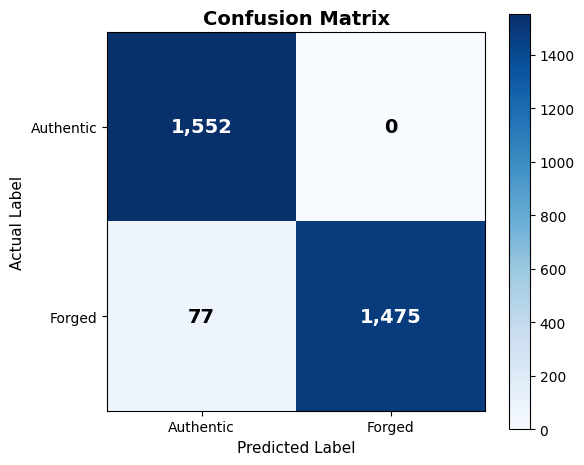

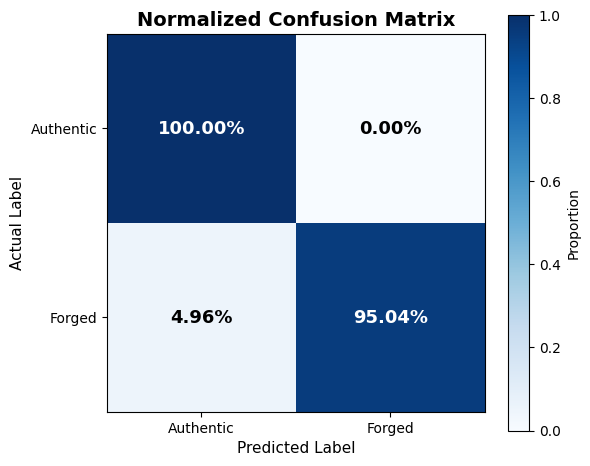

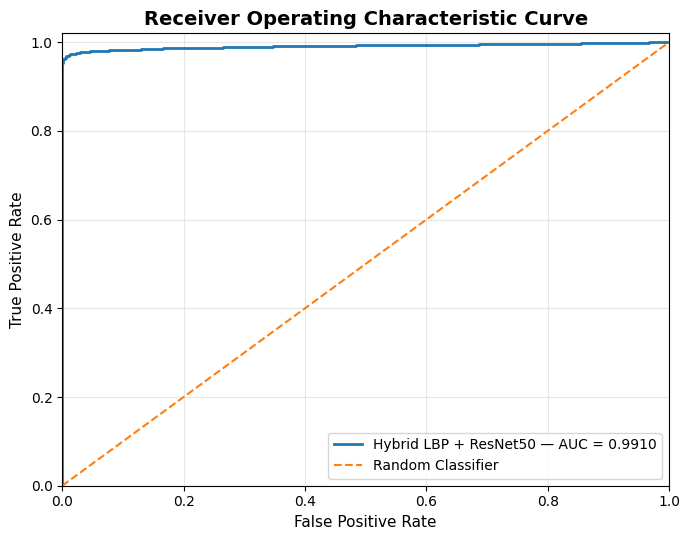

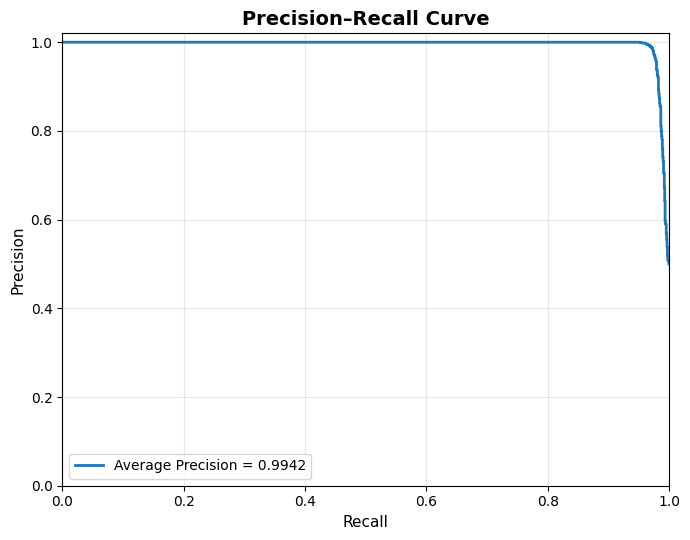

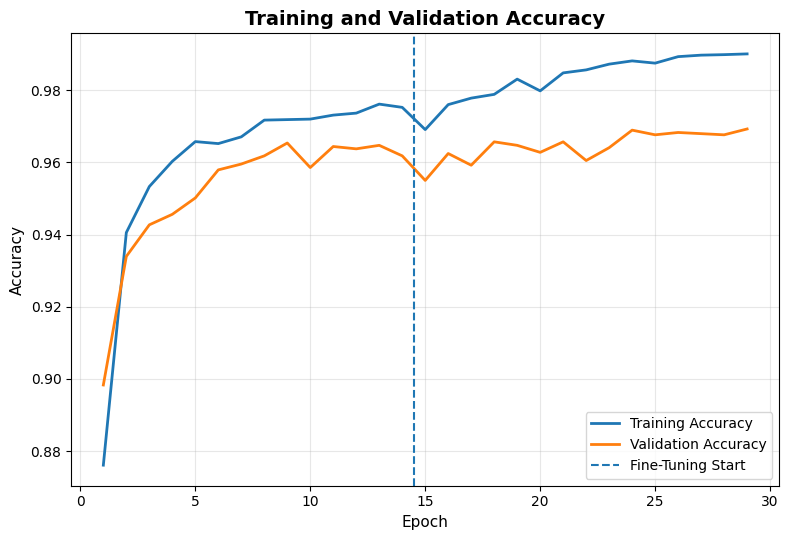

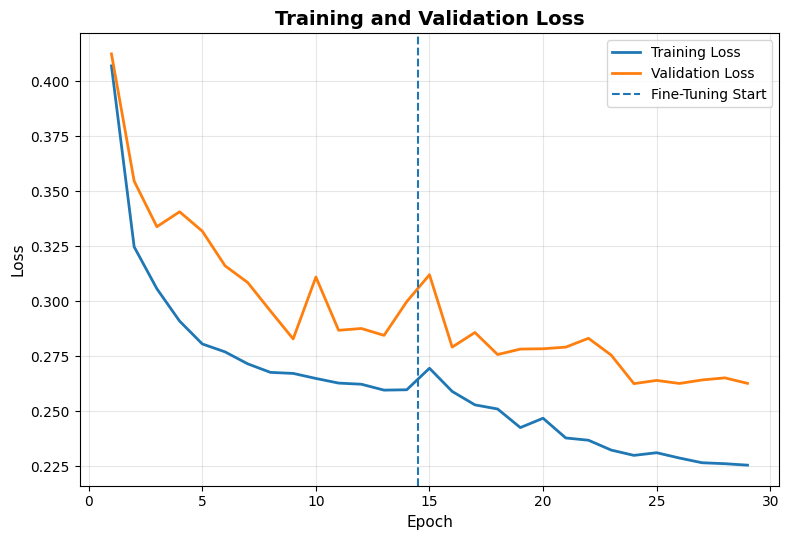

ALL PLOTS SAVED SUCCESSFULLY
Folder: /kaggle/working/final_plots
✓ confusion_matrix_counts.png
✓ confusion_matrix_normalized.png
✓ precision_recall_curve.png
✓ roc_curve.png
✓ training_validation_accuracy.png
✓ training_validation_loss.png


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ============================================================
# Output folder
# ============================================================
PLOTS_DIR = "/kaggle/working/final_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

class_names = ["Authentic", "Forged"]

# ============================================================
# 1. Confusion Matrix — Counts
# ============================================================
plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

threshold_color = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=14,
            fontweight="bold",
            color="white" if cm[i, j] > threshold_color else "black"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "confusion_matrix_counts.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. Normalized Confusion Matrix — Percentages
# ============================================================
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(
    "Normalized Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("Actual Label", fontsize=11)

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_normalized[i, j] * 100:.2f}%",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=13,
            fontweight="bold",
            color="white" if cm_normalized[i, j] > 0.5 else "black"
        )

plt.colorbar(label="Proportion")
plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "confusion_matrix_normalized.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5.5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Hybrid LBP + ResNet50 — AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("Receiver Operating Characteristic Curve", fontsize=14, fontweight="bold")

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.grid(alpha=0.3)
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "roc_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. Precision–Recall Curve
# ============================================================
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7, 5.5))

plt.plot(
    recall_vals,
    precision_vals,
    linewidth=2,
    label=f"Average Precision = {average_precision:.4f}"
)

plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision–Recall Curve", fontsize=14, fontweight="bold")

plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.grid(alpha=0.3)
plt.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "precision_recall_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. Combine Phase 1 and Phase 2 Training History
# ============================================================
acc_all = (
    h1.history["accuracy"]
    + h2.history["accuracy"]
)

val_acc_all = (
    h1.history["val_accuracy"]
    + h2.history["val_accuracy"]
)

loss_all = (
    h1.history["loss"]
    + h2.history["loss"]
)

val_loss_all = (
    h1.history["val_loss"]
    + h2.history["val_loss"]
)

# Epoch numbers start from 1
epochs_all = np.arange(1, len(acc_all) + 1)

# Phase 2 begins after the last Phase 1 epoch
fine_tune_boundary = len(h1.history["accuracy"]) + 0.5


# ============================================================
# 6. Training and Validation Accuracy
# ============================================================
plt.figure(figsize=(8, 5.5))

plt.plot(
    epochs_all,
    acc_all,
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs_all,
    val_acc_all,
    linewidth=2,
    label="Validation Accuracy"
)

plt.axvline(
    x=fine_tune_boundary,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Start"
)

plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.title("Training and Validation Accuracy", fontsize=14, fontweight="bold")

plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "training_validation_accuracy.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. Training and Validation Loss
# ============================================================
plt.figure(figsize=(8, 5.5))

plt.plot(
    epochs_all,
    loss_all,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_all,
    val_loss_all,
    linewidth=2,
    label="Validation Loss"
)

plt.axvline(
    x=fine_tune_boundary,
    linestyle="--",
    linewidth=1.5,
    label="Fine-Tuning Start"
)

plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss", fontsize=11)
plt.title("Training and Validation Loss", fontsize=14, fontweight="bold")

plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "training_validation_loss.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Final confirmation
# ============================================================
print("=" * 60)
print("ALL PLOTS SAVED SUCCESSFULLY")
print("=" * 60)
print(f"Folder: {PLOTS_DIR}")

for filename in sorted(os.listdir(PLOTS_DIR)):
    print(f"✓ {filename}")

### **14. Save Final Model**

In [19]:
FINAL_MODEL_PATH = (
    "/kaggle/working/"
    "paper_fingerprint_hybrid_lbp_resnet50_final.keras"
)

model.save(
    FINAL_MODEL_PATH
)

print(
    "Model saved:",
    FINAL_MODEL_PATH
)

Model saved: /kaggle/working/paper_fingerprint_hybrid_lbp_resnet50_final.keras


In [20]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/best_hybrid_lbp_resnet50.keras"
)

test_results = best_model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test AUC:", test_results[2])

194/194 ━━━━━━━━━━━━━━━━━━━━ 56s 267ms/step - accuracy: 0.9752 - auc: 0.9911 - loss: 0.2519
Test Loss: 0.2518661618232727
Test Accuracy: 0.9751933217048645
Test AUC: 0.9911431670188904


In [21]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

y_true = []
y_pred = []

for x, y in test_ds:
    pred = best_model.predict(x, verbose=0)
    pred = (pred > 0.5).astype(int).flatten()

    y_true.extend(y.numpy())
    y_pred.extend(pred)

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

2026-07-25 16:21:33.742109: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-07-25 16:21:38.898198: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Precision: 1.0
Recall: 0.9503865979381443
F1-score: 0.9745622728774364

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98      1552
         1.0       1.00      0.95      0.97      1552

    accuracy                           0.98      3104
   macro avg       0.98      0.98      0.98      3104
weighted avg       0.98      0.98      0.98      3104


Confusion Matrix:
[[1552    0]
 [  77 1475]]


In [22]:
import shutil
DATASET_OUT     = '/kaggle/working/GraduationProject/Dataset_v2'
AUTH_OUT        = os.path.join(DATASET_OUT, 'Authentic')
FORGED_OUT      = os.path.join(DATASET_OUT, 'Forged')

shutil.make_archive(
    "/kaggle/working/Test_Authentic",
    "zip",
    "/kaggle/working/GraduationProject/Dataset_v2/Authentic/test"
)

shutil.make_archive(
    "/kaggle/working/Test_Forged",
    "zip",
    "/kaggle/working/GraduationProject/Dataset_v2/Forged/test"
)

print("Done!")

Done!
